# BeliefLens SPY/SGOV frozen public reproduction

This notebook reproduces the published SPY/SGOV example from the immutable `GET /v1/examples/SPY-trading` demonstration. It displays the point-in-time evidence, benchmark design, frozen semantic map, calibration diagnostics, calibrated decisions, and comparative portfolio results.

The demonstration is keyless and non-configurable. It attempts one BeliefLens request, performs no model inference, and incurs no provider cost. If the public route is unavailable, it loads the archived copy of the same API response. The bundle beside this notebook supplies the frozen source records used for transparent inspection. For experiments using your own evidence and model, use the separate authenticated notebook in this directory.


In [1]:
from pathlib import Path
from io import BytesIO
import atexit, json, os, subprocess, sys, time, uuid, zipfile
import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')
BELIEFLENS_URL = os.getenv('BELIEFLENS_URL', 'https://demo.belieflens.org')
bundle_suffix = Path('outputs/belieflens-current-state-spy-sgov-v4/offline_reproduction')
candidates = [Path.cwd()/bundle_suffix, Path.cwd()/'engine'/bundle_suffix, Path.cwd()/'examples/notebooks/finance/data/offline_reproduction', Path.cwd()/'data/offline_reproduction', Path.cwd().parents[1]/bundle_suffix]
BUNDLE = next((path.resolve() for path in candidates if path.exists()), candidates[0])
assert BUNDLE.exists(), f'Frozen bundle not found: {BUNDLE}'
BUNDLE

PosixPath('/Users/matthewdixon_1/Downloads/codex-workspace/papers/BeliefBench-Server/engine/outputs/belieflens-current-state-spy-sgov-v4/offline_reproduction')

## 1. Load the immutable public demonstration

This keyless route returns a CDN-cacheable canonical result. It is intentionally not configurable and performs no model or analysis computation.

In [ ]:
def load_public_demo():
    url = BELIEFLENS_URL.rstrip('/') + '/v1/examples/SPY-trading'
    try:
        response = httpx.get(url, timeout=15, follow_redirects=False)
        response.raise_for_status()
        result = response.json()
        result['_reproduction_source'] = 'live immutable endpoint'
        return result
    except (httpx.HTTPError, json.JSONDecodeError):
        archived = json.loads((BUNDLE/'API_REPRODUCTION_RESULT.json').read_text())
        archived['_reproduction_source'] = 'archived immutable API response'
        return archived

result = load_public_demo()

pd.Series({
    'source': result['_reproduction_source'],
    'endpoint': result['endpoint'],
    'reproduction passed': result['reproduction_passed'],
    'provider API calls': result['provider_api_calls'],
    'demo mode': result.get('demo_mode', 'immutable'),
    'configurable': result.get('configurable', False),
    'map maximum error': result['frozen_semantic_map_max_abs_error'],
    'diagnostic maximum error': result['diagnostic_max_abs_error'],
    'portfolio maximum error': result['portfolio_metric_max_abs_error'],
}, name='API reproduction')


## 2. Input evidence and benchmark design
The evidence below is point-in-time market information supplied to the frozen language measurement. Future returns are used only for the secondary portfolio evaluation.

In [3]:
records = pd.DataFrame(json.loads(line) for line in (BUNDLE/'inputs/records.jsonl').read_text().splitlines() if line.strip())
records[['observation_id', 'decision_date', 'partition', 'reference_state', 'evidence_text']].head(5)

,observation_id,decision_date,partition,reference_state,evidence_text
0,daily-2018-01-10,2018-01-10,calibration,Risk-on,"As of 2018-01-10, SPY returned +1.3% over five trading days and +4.0% over twenty. Trailing twen..."
1,daily-2018-01-29,2018-01-29,calibration,Risk-on,"As of 2018-01-29, SPY returned +0.7% over five trading days and +6.3% over twenty. Trailing twen..."
2,daily-2018-02-09,2018-02-09,calibration,Risk-off,"As of 2018-02-09, SPY returned -5.0% over five trading days and -5.2% over twenty. Trailing twen..."
3,daily-2018-02-12,2018-02-12,calibration,Risk-off,"As of 2018-02-12, SPY returned +0.5% over five trading days and -4.5% over twenty. Trailing twen..."
4,daily-2018-03-05,2018-03-05,calibration,Risk-off,"As of 2018-03-05, SPY returned -2.1% over five trading days and -1.2% over twenty. Trailing twen..."


In [4]:
benchmark_counts = pd.crosstab(records['partition'], records['reference_state']).reindex(
    ['calibration', 'prompt_validation', 'conformal', 'test'], fill_value=0
)
benchmark_counts['Total'] = benchmark_counts.sum(axis=1)
benchmark_counts.loc['Total'] = benchmark_counts.sum(axis=0)
benchmark_counts

reference_state,Mixed,Risk-off,Risk-on,Total
partition,,,,
calibration,60,60,60,180
prompt_validation,15,15,15,45
conformal,20,20,20,60
test,22,67,38,127
Total,117,162,133,412


## 3. Frozen semantic map and calibration diagnostics

In [5]:
semantic_map = json.loads((BUNDLE/'semantic_map.json').read_text())
pd.Series({
    'states': ', '.join(semantic_map['states']),
    'input candidates': ', '.join(semantic_map['input_candidates']),
    'transform': semantic_map['input_transform'],
    'calibration observations': len(semantic_map['calibration_scenario_ids']),
    'estimator': semantic_map['model_type'],
    'ridge C': semantic_map['regularization_C'],
}, name='Calibrated semantic map')

states                                     Risk-on, Mixed, Risk-off
input candidates                   Risk-on, Mixed, Risk-off, Unsure
transform                         additive log ratio against Unsure
calibration observations                                        180
estimator                   sklearn.linear_model.LogisticRegression
ridge C                                                         1.0
Name: Calibrated semantic map, dtype: object

In [6]:
d = result['measurement_diagnostics']
diagnostic_table = pd.DataFrame([
    ('Held-out accuracy', d['held_out_recovery']['accuracy'], 'higher is better'),
    ('Held-out log loss', d['held_out_recovery']['log_loss'], 'lower is better'),
    ('Held-out Brier score', d['held_out_recovery']['multiclass_brier'], 'lower is better'),
    ('Mean JS posterior error', d['held_out_recovery']['mean_js_error'], 'lower is better'),
    ('Conformal coverage', d['conformal_coverage']['empirical'], f"nominal = {d['conformal_coverage']['nominal']:.0%}"),
    ('Prompt perturbation JS', d['prompt_stability']['mean_js'], 'lower is more stable'),
    ('Normalized state entropy', d['uncertainty']['mean_normalized_state_entropy'], 'state uncertainty'),
    ('Observed candidate mass', d['uncertainty']['mean_observed_candidate_mass'], 'higher is better'),
    ('Lexical–elicited JS', d['elicited_discrepancy']['mean_js_lexical_vs_elicited'], 'channel disagreement'),
], columns=['Diagnostic', 'Value', 'Interpretation'])
diagnostic_table.style.format({'Value': '{:.4f}'})

,Diagnostic,Value,Interpretation
0,Held-out accuracy,0.3780,higher is better
1,Held-out log loss,0.7680,lower is better
2,Held-out Brier score,0.4883,lower is better
3,Mean JS posterior error,0.2217,lower is better
4,Conformal coverage,0.8898,nominal = 90%
5,Prompt perturbation JS,0.0156,lower is more stable
6,Normalized state entropy,0.7239,state uncertainty
7,Observed candidate mass,0.9990,higher is better
8,Lexical–elicited JS,0.0513,channel disagreement


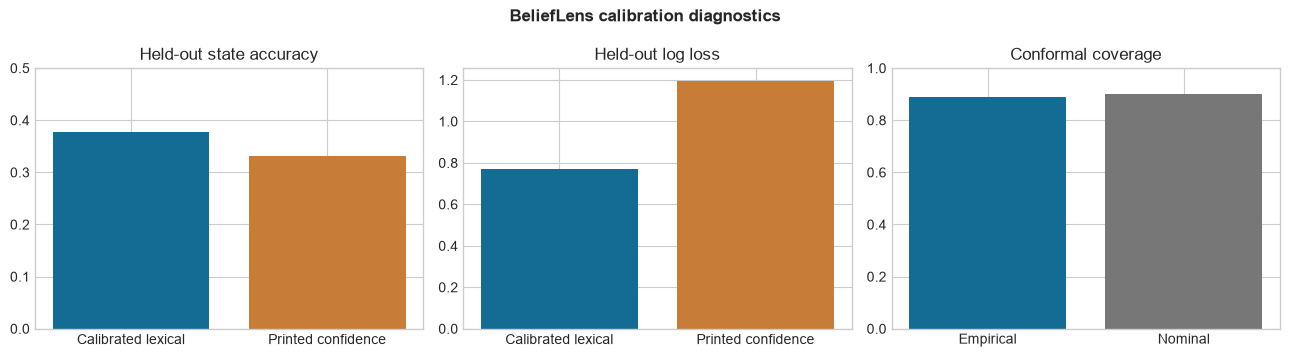

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
recovery = d['held_out_recovery']; printed = d['printed_probability_recovery']
axes[0].bar(['Calibrated lexical', 'Printed confidence'], [recovery['accuracy'], printed['accuracy']], color=['#146c94', '#c77d38'])
axes[0].set_title('Held-out state accuracy'); axes[0].set_ylim(0, .5)
axes[1].bar(['Calibrated lexical', 'Printed confidence'], [recovery['log_loss'], printed['log_loss']], color=['#146c94', '#c77d38'])
axes[1].set_title('Held-out log loss')
axes[2].bar(['Empirical', 'Nominal'], [d['conformal_coverage']['empirical'], d['conformal_coverage']['nominal']], color=['#146c94', '#777777'])
axes[2].set_title('Conformal coverage'); axes[2].set_ylim(0, 1)
fig.suptitle('BeliefLens calibration diagnostics', fontweight='bold'); fig.tight_layout()

## 4. Calibrated benchmark decisions

In [8]:
rows = pd.read_csv(BUNDLE/'row_level_measurements.csv')
rows['SPY_weight'] = rows['calibrated_risk_on'] + 0.5 * rows['calibrated_mixed']
decision_columns = ['date', 'partition', 'external_regime', 'raw_risk_on', 'raw_mixed', 'raw_risk_off', 'raw_unsure',
                    'calibrated_risk_on', 'calibrated_mixed', 'calibrated_risk_off', 'SPY_weight',
                    'portfolio_spy_return', 'portfolio_safe_return']
rows.loc[rows.partition == 'test', decision_columns].head(8).style.format({column: '{:.4f}' for column in decision_columns if column not in {'date', 'partition', 'external_regime'}})

,date,partition,external_regime,raw_risk_on,raw_mixed,raw_risk_off,raw_unsure,calibrated_risk_on,calibrated_mixed,calibrated_risk_off,SPY_weight,portfolio_spy_return,portfolio_safe_return
285,2026-01-02,test,Mixed,0.9047,0.0953,0.0000,0.0000,0.2664,0.7329,0.0007,0.6328,0.0067,0.0001
286,2026-01-05,test,Mixed,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,0.0059,0.0001
287,2026-01-06,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,-0.0032,0.0001
288,2026-01-07,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,-0.0001,0.0001
289,2026-01-08,test,Mixed,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,0.0066,0.0002
290,2026-01-09,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,0.0016,0.0002
291,2026-01-12,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,-0.0020,0.0001
292,2026-01-13,test,Risk-on,1.0000,0.0000,0.0000,0.0000,0.6308,0.3454,0.0238,0.8035,-0.0049,0.0001


## 5. Comparative SPY/SGOV evaluation
The portfolio comparison is a secondary illustrative evaluation, not a profitability or trading claim. All allocations use the same next-day total-return series and five-basis-point turnover cost where applicable.

In [9]:
performance = pd.DataFrame(result['portfolio_metrics']).T.rename(columns={
    'annualized_return': 'Annual return', 'annualized_volatility': 'Annual volatility',
    'excess_sharpe_vs_sgov': 'Excess Sharpe vs SGOV', 'maximum_drawdown': 'Maximum drawdown',
    'total_return': 'Total return', 'observations': 'Observations'
})
display(performance[['Observations', 'Annual return', 'Annual volatility', 'Excess Sharpe vs SGOV', 'Maximum drawdown']].style.format({
    'Observations': '{:.0f}', 'Annual return': '{:.1%}', 'Annual volatility': '{:.1%}',
    'Excess Sharpe vs SGOV': '{:.2f}', 'Maximum drawdown': '{:.1%}'
}).highlight_max(subset=['Excess Sharpe vs SGOV'], color='#c7efd9').highlight_min(subset=['Maximum drawdown'], color='#c7efd9'))

,Observations,Annual return,Annual volatility,Excess Sharpe vs SGOV,Maximum drawdown
SPY,127,20.1%,14.1%,1.12,8.9%
SGOV,127,3.7%,0.2%,nan,0.0%
fixed_50_50,127,11.9%,7.0%,1.12,4.2%
blind_GPT_no_market_evidence,127,3.7%,0.2%,nan,0.0%
blind_GPT_direct_recommendation,127,11.3%,8.1%,0.91,5.3%
direct_GPT_recommendation,127,13.7%,9.5%,1.02,4.9%
data_assisted_GPT_elicited,127,10.6%,8.8%,0.77,5.2%
BeliefLens_calibrated_lexical,127,12.8%,7.2%,1.21,3.1%


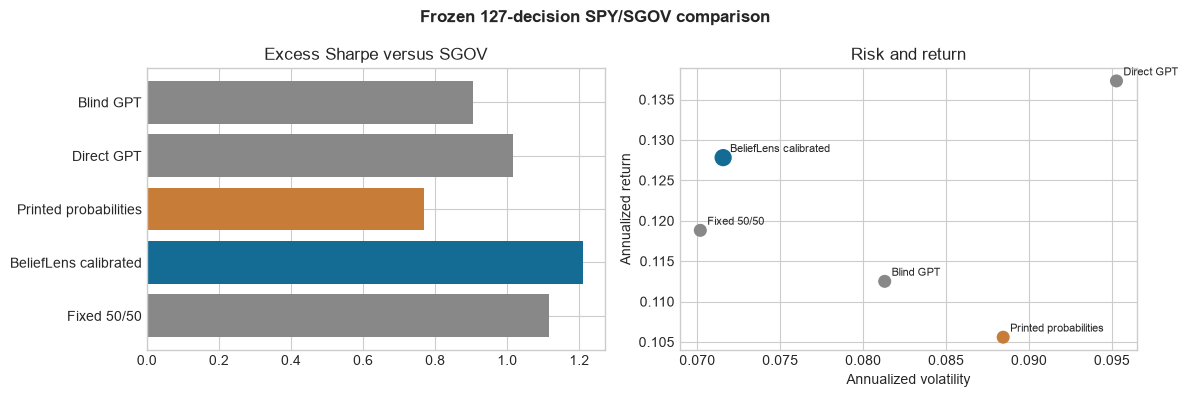

In [10]:
plot_names = ['blind_GPT_direct_recommendation', 'direct_GPT_recommendation', 'data_assisted_GPT_elicited', 'BeliefLens_calibrated_lexical', 'fixed_50_50']
labels = ['Blind GPT', 'Direct GPT', 'Printed probabilities', 'BeliefLens calibrated', 'Fixed 50/50']
view = performance.loc[plot_names]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(labels, view['Excess Sharpe vs SGOV'], color=['#888888', '#888888', '#c77d38', '#146c94', '#888888'])
axes[0].set_title('Excess Sharpe versus SGOV'); axes[0].invert_yaxis()
axes[1].scatter(view['Annual volatility'], view['Annual return'], s=[70, 70, 70, 130, 70], color=['#888888', '#888888', '#c77d38', '#146c94', '#888888'])
for label, x, y in zip(labels, view['Annual volatility'], view['Annual return']): axes[1].annotate(label, (x, y), xytext=(5, 4), textcoords='offset points', fontsize=8)
axes[1].set_xlabel('Annualized volatility'); axes[1].set_ylabel('Annualized return'); axes[1].set_title('Risk and return')
fig.suptitle('Frozen 127-decision SPY/SGOV comparison', fontweight='bold'); fig.tight_layout()

## Interpretation and audit boundary

The public endpoint returns a verified frozen result with **one keyless BeliefLens request and zero provider calls**. It reproduces a declared semantic-state measurement and its secondary portfolio evaluation; it does not retrain the semantic map, accept user data, or certify future profitability.

To construct a private benchmark, estimate cost before execution, run new model observations, and obtain a new calibration certificate, continue with [`SPY_SGOV_authenticated_workflow.ipynb`](SPY_SGOV_authenticated_workflow.ipynb).
